# Video: Modeling Convergence Using Eigendecompositions

In this video, you will see how eigendecompositions can be used to reason about the convergence of common machine learning optimizations including linear regression.

[![View on GitHub](https://img.shields.io/badge/GitHub-181717?logo=github&logoColor=white)](https://github.com/bu-cds-omds/dx601-examples/blob/main/week12/video_modeling_convergence_using_eigendecompositions.ipynb)
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bu-cds-omds/dx601-examples/blob/main/week12/video_modeling_convergence_using_eigendecompositions.ipynb)



Script:
* In this video, we will peek ahead at the optimization of quadratic objective functions used in machine learning problems.
* We will see that eigendecompositions can help simplify the analysis of the optimization's convergence to the optimal answer.

## An Example Objective Function


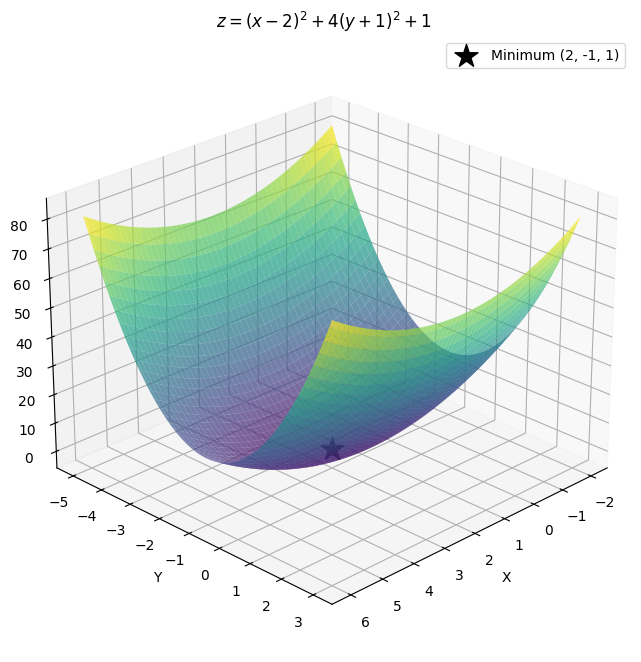

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define the function
def f(x, y):
    return (x - 2)**2 + 4 * (y + 1)**2 + 1

# Create a grid of points
x = np.linspace(-2, 6, 100)
y = np.linspace(-5, 3, 100)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)

# Minimum point coordinates
x_min, y_min = 2, -1
z_min = f(x_min, y_min)

# Plotting
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Surface plot
surf = ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.7, edgecolor='none')

# Make the marker black: use a large black star and a vertical line to the floor
ax.scatter([x_min], [y_min], [z_min], color='black', marker='*', s=300, label=f'Minimum (2, -1, 1)', zorder=5)
ax.plot([x_min, x_min], [y_min, y_min], [0, z_min], color='black', linestyle='--', linewidth=2)

# Labels and title
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('$z = (x-2)^2 + 4(y+1)^2 + 1$')
ax.legend()

# Adjust view for better visibility of the point
ax.view_init(elev=25, azim=45)

plt.show()

Script:
* Here's an example function that we might want to optimize.
* It takes in two input variables x and y, and we want to find the choice of x and y that will minimize the function.
* In this chart, the minimum is marked by a star.

## Quadratic Optimization Setup

Setup:

\begin{array}{rcl}
f(x) & = & ax^2 + bx + c \\
f(\mathbf{x}) & = & \frac{1}{2} \mathbf{x}^\top \mathbf{A} \mathbf{x} + \mathbf{b}^\top \mathbf{x} + c
\end{array}

Goal:

* Find $\mathbf{x}$ minimizing $f(\mathbf{x})$.

Constraint:

* $\mathbf{A}$ is symmetric positive definite.


Script:
* For this video, I'll focus on quadratic functions.
* You may recall the first version, $ax^2 + bc + c$ from high school.
* The second version is a vector form that can handle more than one input variable.
* $1/2 \mathbf{x}^\top \mathbf{A} \mathbf{x} + \mathbf{b}^\top \mathbf{x} + c$.
* We will focus on this second version.
* Our goal will be minimizing $f(\mathbf{x})$.
* To make this feasible, we will only consider problems where $\mathbf{A}$ to be positive definite which will make $f$ convex.

## Why Positive Definite?


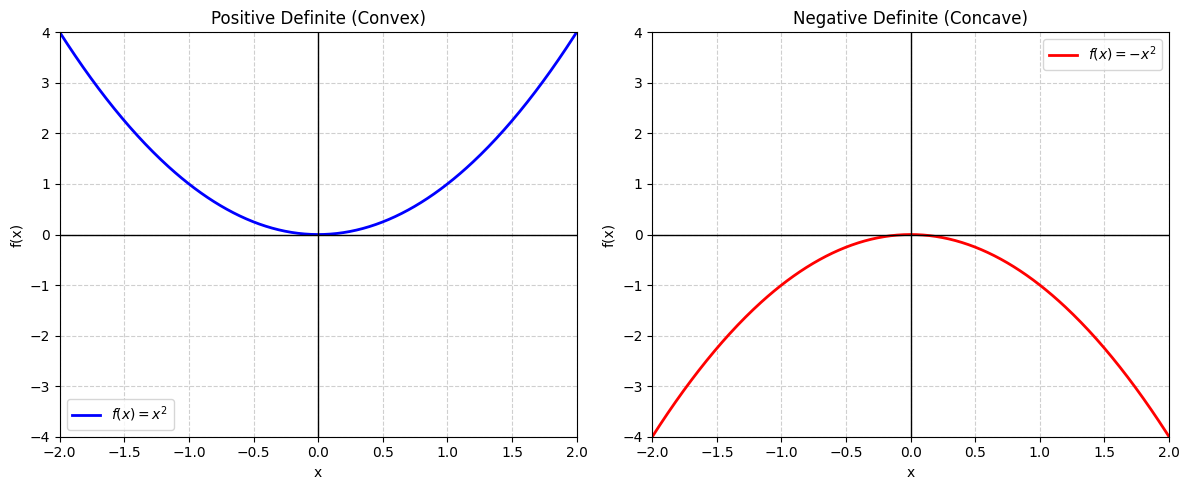

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-2, 2, 400)
y_pos = x**2
y_neg = -x**2

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left plot: Positive Definite
axes[0].plot(x, y_pos, linewidth=2, color='blue', label='$f(x) = x^2$')
axes[0].set_title("Positive Definite (Convex)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("f(x)")
axes[0].set_xlim([-2, 2])
axes[0].set_ylim([-4, 4])
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].axhline(0, color='black', linewidth=1)
axes[0].axvline(0, color='black', linewidth=1)
axes[0].legend()

# Right plot: Negative Definite
axes[1].plot(x, y_neg, linewidth=2, color='red', label='$f(x) = -x^2$')
axes[1].set_title("Negative Definite (Concave)")
axes[1].set_xlabel("x")
axes[1].set_ylabel("f(x)")
axes[1].set_xlim([-2, 2])
axes[1].set_ylim([-4, 4])
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].axvline(0, color='black', linewidth=1)
axes[1].legend()

plt.tight_layout()
plt.show()

Script:
* Here's an example of why $\mathbf{A}$ should be positive definite.
* If $\mathbf{A}$ is positive definite like on the left, then $f$ will be convex and there will be a minimum.
* The left function $f(x)=x^2$ is such an example.
* On the other hand, if $\mathbf{A}$ is negative definite like on the right, then there is no minimum.

## Why Symmetric?

Real symmetric matrices have orthonormal bases of eigenvectors by the spectral theorem.
* This means we can use eigendecompositions later.

Script:
* What about the symmetry requirement for $\mathbf{A}$?
* We will want that later so that we can use eigendecompositions later.
* First, the spectral theorem tells us that orthonormal bases of eigenvectors exist for $\mathbf{A}$.
* Second, that means $\mathbf{A}$ meets the requirements for diagonalization.
* Not only will we have eigendecompositions, but we can make use of orthonorml eigendecompositions.

## Example: Ordinary Least Squares Linear Regression

$L(\theta) = \sum_{i=1}^n (h_\theta(\mathbf{x}_i) - y_i)^2$

Note: this function is quadratic in $\theta$ but $\mathbf{A}$, $\mathbf{b}$, and $c$ are not explicitly given.

Script:
* Quadratic optimization problems pop up regularly in machine learning, even if they are not expressed in terms of $\mathbf{A}$, $\mathbf{b}$, and $c$.
* For example, ordinary least squares linear regression, the most common form of model, is expressed as a sum of squared errors between the model predictions and the actual values.
* Each prediction is linear, so the error is linear, and the squared error is quadratic.
* Summing many quadratic errors is still quadratic.
* $\mathbf{A}$, $\mathbf{b}$, and $c$ can be computed, but this may be inconvenient if there are a lot of input variables.
* If there are $n$ input variables, $\mathbf{A}$ has dimensions $n \times n$.

## Two Approaches to Minimizing a Function

1. Solve for where the function is "flat".
2. Follow the function "downwards" to lower function outputs.

Both depend on calculating the gradient of the function.

Script:
* There are two archetypal ways to minimize a function.
* The first is to solve for where the function is flat, and prove or assume that only happens at the minimum.
* The second is to iteratively improve a guess based on the slope of the function.

Both of these methods depend on modeling the gradient of the function.

## Gradient of the Objective Function

Gradient of function:

$\nabla f(\mathbf{x})$

How fast does $f(\mathbf{x})$ change when $\mathbf{x}$ changes?

Script:
* What is the gradient of a function?
* Briefly, it is the rate of change in the value of the function when you make very small changes to the inputs.
* More specifically, the gradient is a vector containing the limits of the rate of change for very small changes in each input dimension.

## A 1D Quadratic Function and A Tangent Line


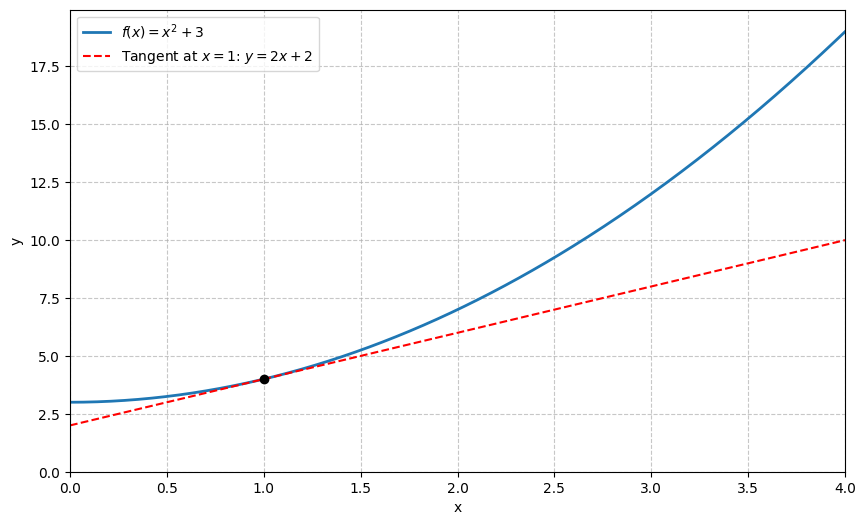

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the function and its derivative
def f(x):
    return x**2 + 3

def df(x):
    return 2*x

# Tangent line at x=1
x0 = 1
y0 = f(x0)
slope = df(x0)
# Formula: y - y0 = slope * (x - x0) => y = slope * x + (y0 - slope * x0)
b = y0 - slope * x0

def tangent_line(x):
    return slope * x + b

# Create x values
x = np.linspace(0, 4, 400)
y = f(x)
y_tangent = tangent_line(x)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(x, y, label='$f(x) = x^2 + 3$', linewidth=2)
plt.plot(x, y_tangent, '--', label=f'Tangent at $x=1$: $y = {slope}x + {b}$', color='red')
plt.scatter([x0], [y0], color='black', zorder=5) # Mark the point of tangency

# plt.title('Function and Tangent Line')
plt.xlabel('x')
plt.ylabel('y')
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(0, 4)
plt.ylim(0)
plt.legend()
plt.show()

Script:
* One way to visualize the gradient is to draw a tangent line or hyperplane.
* The vector of coefficients for each dimension will be the gradient.
* In this example, the tangent line is drawn at $x=1$, and the coefficient of $x$ is 2, so the gradient is a vector with one value 2.

## A 2D Quadratic Function and A Tangent Plane


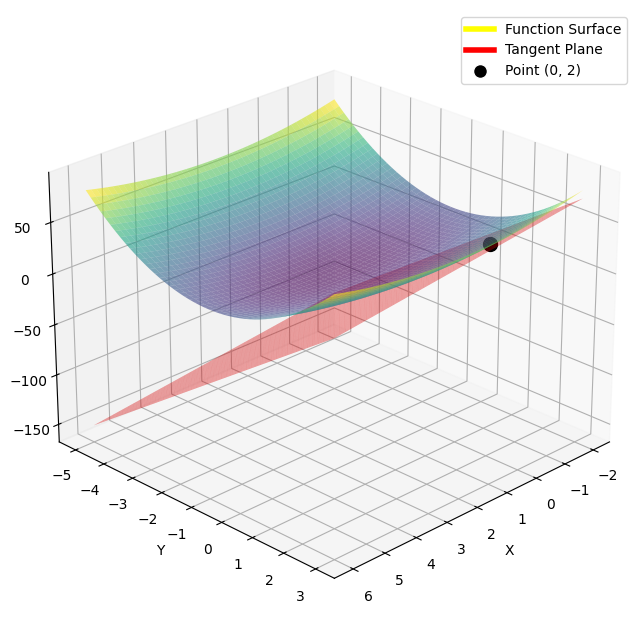

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define the function and its partial derivatives
def f(x, y):
    return (x - 2)**2 + 4 * (y + 1)**2 + 1

def df_dx(x, y):
    return 2 * (x - 2)

def df_dy(x, y):
    return 8 * (y + 1)

# Point of tangency
x0, y0 = 0, 2
z0 = f(x0, y0)
dz_dx = df_dx(x0, y0)
dz_dy = df_dy(x0, y0)

# Tangent hyperplane equation: z = dz_dx*(x - x0) + dz_dy*(y - y0) + z0
def tangent_plane(x, y):
    return dz_dx * (x - x0) + dz_dy * (y - y0) + z0

# Create grid with requested ranges
x_range = np.linspace(-2, 6, 50)
y_range = np.linspace(-5, 3, 50)
X, Y = np.meshgrid(x_range, y_range)
Z = f(X, Y)
Z_tangent = tangent_plane(X, Y)

# Plotting
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Surface plot
surf = ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.6)
# Tangent Plane
ax.plot_surface(X, Y, Z_tangent, color='red', alpha=0.4)
# Tangency point
ax.scatter([x0], [y0], [z0], color='black', s=100)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
# ax.set_title(f'$f(x,y) = (x-2)^2 + 4(y+1)^2 + 1$ and Tangent Plane')

# Set viewing angle
ax.view_init(elev=25, azim=45)

# Simple proxy for legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color='yellow', lw=4, label='Function Surface'),
                   Line2D([0], [0], color='red', lw=4, label='Tangent Plane'),
                   Line2D([0], [0], marker='o', color='w', label=f'Point ({x0}, {y0})', markerfacecolor='black', markersize=10)]
ax.legend(handles=legend_elements)

plt.show()

Script:
* This example repeats the previous 2 variable quadratic function, and shows a tangent plane.
* The slopes of that tangent plane give you the gradient at that point.

## Optimization of a Quadratic Objective Function

Original function:

$f(\mathbf{x}) = \frac{1}{2} \mathbf{x}^\top \mathbf{A} \mathbf{x} + \mathbf{b}^\top \mathbf{x} + c$

Gradient:

$\nabla f(\mathbf{x}) = \mathbf{A} \mathbf{x} + \mathbf{b}$


Script:
* If we know the values of $\mathbf{A}$, $\mathbf{b}$ and $c$, we can calculate the gradient easily using matrix calculus.
* If you have not taken multivariate calculus or it has been a while, the formula is just $\mathbf{A}\mathbf{x} + \mathbf{b}$.

## Direct Solution

Let $\mathbf{x}^\ast$ be the optimal solution and set its gradient to zero.

\begin{array}{rcl}
\nabla f(\mathbf{x}) & = & \mathbf{A} \mathbf{x}^\ast + \mathbf{b} \\
\mathbf{A} \mathbf{x}^\ast + \mathbf{b} & = & 0 \\
\mathbf{A} \mathbf{x}^\ast & = & - \mathbf{b} \\
\mathbf{x}^\ast & = & - \mathbf{A}^{-1} \mathbf{b} \\
\end{array}

Script:
* We can use the gradient formula to directly solve for when the gradient is zero which will give a local minima or maxima.
* I will call the value of $x$ where the gradient is zero $x^\ast$.
* Assuming that the function is convex, this will be the global minimum of $f$.
* We will come back to that assumption later.
* $\mathbf{A}\mathbf{x}^\ast + \mathbf{b} = 0$.
* With a little linear algebra, we can solve for $\mathbf{x}^\ast$ with matrix inversion or your favorite faster solver.
* If you know $\mathbf{A}$ and $\mathbf{b}$ and they aren't too big, this is a fine solution, but I'm going to also talk about solving minimizing this function with gradient descent.

## Gradient Descent Idea

Compute a sequence $\mathbf{x}_0, \mathbf{x}_1, \mathbf{x}_2, \ldots$ with $f(\mathbf{x}_0) > f(\mathbf{x}_1) > f(\mathbf{x}_2) > \ldots$


Script:
* The idea of gradient descent is that we are going to use the gradients to calculate a sequence of estimates of $\mathbf{x}^\ast$ that get closer and closer to $\mathbf{x}^\ast$ with smaller and smaller outputs from the function $f$.
* How can we do that?

## Gradient Descent Updates

Update $\mathbf{x}_{t+1}$ in the direction that $\nabla f(\mathbf{x}_t)$ says will decrease the $f()$.

\begin{array}{rcl}
\mathbf{x}_{t+1} & = & \mathbf{x}_t - \alpha \nabla f(\mathbf{x}_t)
\end{array}


Script:
* For each estimate $\mathbf{x}_t$ of $\mathbf{x}^\ast$, we will compute the gradient of $f$ at $\mathbf{x}_t$.
* Then we will calculate a new $\mathbf{x}_{t+1}$ that moves in the opposite direction of the gradient.
* So, if the gradient says that increasing the first input value increases $f$, then we will decrease the first input value.
* And if the gradient says that increasing the first input value decreases $f$, then we will increase the first input value.
* This will be done for each component of $\mathbf{x}_t$ simultaneously.
* This gives a simple update formula.
* The new $\mathbf{x}_{t+1}$ is the old $\mathbf{x}_t$ minus $\alpha$ times the gradient of $f$ at $\mathbf{x}_t$.
* What's $\alpha$?
* $\alpha$ is a small positive parameter that we call the learning rate.
* I'll come back to that shortly.
* A key feature of gradient descent is that you can use it as long as you can calculate the gradient, and you do not need the function $f$ to be in a particular form.
* In particular, you do not need to know $\mathbf{A}$, $\mathbf{b}$ or $c$.
* In some cases, like our linear regression example, it will be more convenient to derive the gradient from the summation formula than to convert to $\mathbf{A}$, $\mathbf{b}$ and $c$.
* So what should the learning rate $\alpha$ be?

## What Makes a Good Learning Rate?


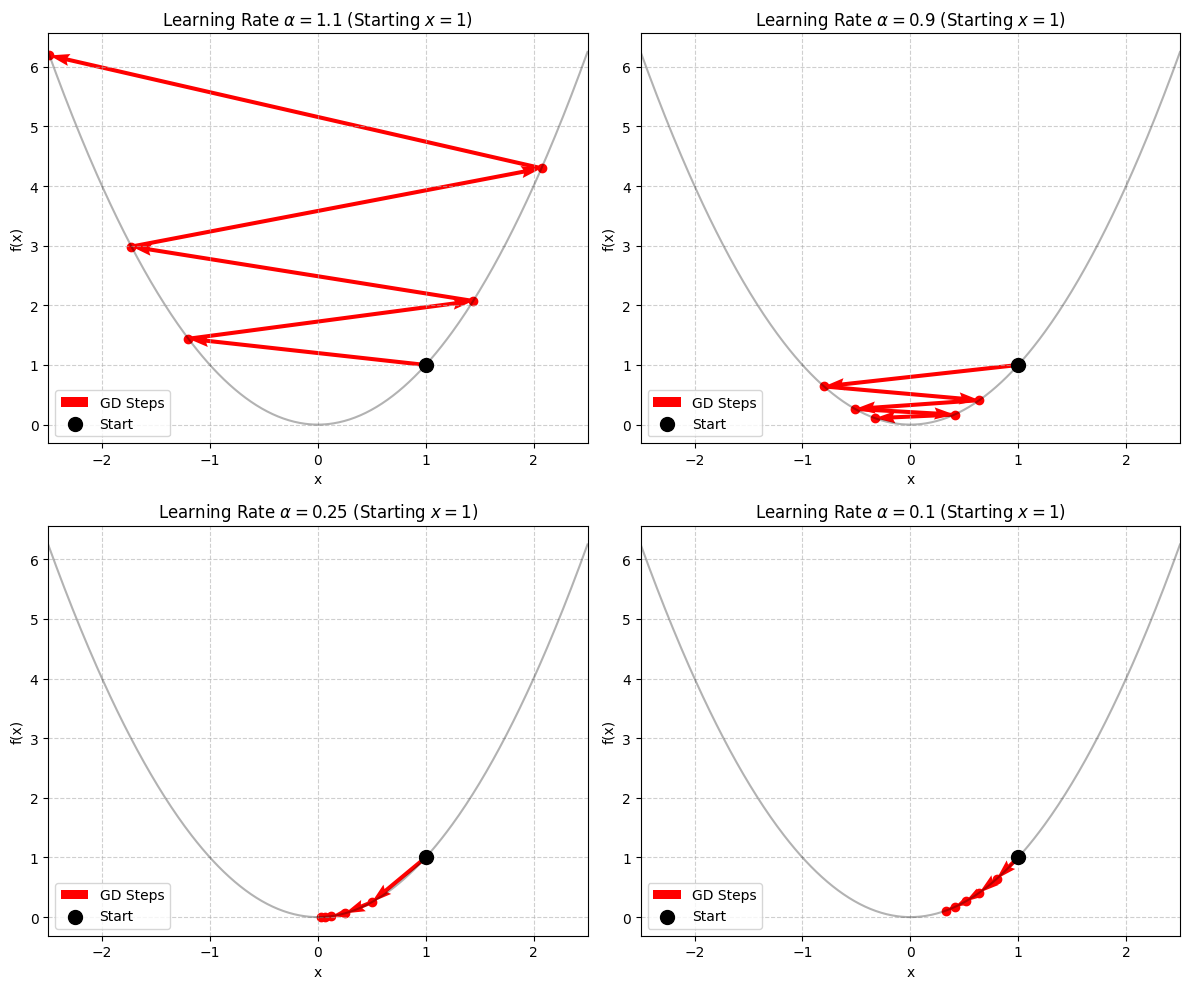

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return x**2

def df(x):
    return 2*x

def run_gradient_descent(start_x, lr, steps):
    history = [start_x]
    curr_x = start_x
    for _ in range(steps):
        curr_x = curr_x - lr * df(curr_x)
        history.append(curr_x)
    return history

# Parameters
x_start = 1.0
steps = 5
lrs = [1.1, 0.9, 0.25, 0.1]

# Changed to 2x2 layout
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
x_vals = np.linspace(-2.5, 2.5, 400)

for i, lr in enumerate(lrs):
    history = run_gradient_descent(x_start, lr, steps)
    axes[i].plot(x_vals, f(x_vals), 'k-', alpha=0.3)

    # Plot steps
    h_x = np.array(history)
    h_y = f(h_x)
    axes[i].quiver(h_x[:-1], h_y[:-1], h_x[1:]-h_x[:-1], h_y[1:]-h_y[:-1],
                   scale_units='xy', angles='xy', scale=1, color='red', label='GD Steps')
    axes[i].scatter(h_x, h_y, color='red')

    # Add a black marker at the starting point
    axes[i].scatter([x_start], [f(x_start)], color='black', s=100, zorder=5, label='Start')

    # Using raw string to handle LaTeX correctly
    axes[i].set_title(fr'Learning Rate $\alpha = {lr}$ (Starting $x=1$)')

    axes[i].set_xlabel('x')
    axes[i].set_xlim(-2.5, 2.5)
    axes[i].set_ylabel('f(x)')
    axes[i].grid(True, linestyle='--', alpha=0.6)
    axes[i].legend()

plt.tight_layout()
plt.show()

Script:
* These charts show gradient descent on the function $f(x)=x^2$.
* The first chart shows a learning rate of 1.1.
* This works poorly because it overshoots and ends up farther away on the opposite side of the parabola.
* It zigzags back and forth and overshoots farther each time, so this attempt at optimization actually made things worse.
* In the top right chart, the learning rate is 0.9.
* Each step still overshoots, but is not quite as far away on the opposite side, so the optimization slowly gets closer.
* In the bottom left, the learning rate is 0.25.
* In this case, the distance to optimal halves with each step, so it gets close pretty quickly.
* In the bottom right, the learning rate is 0.1.
* In this case, the learning rate was too slow or more steps were needed since it ended up much farther away.
* The first two of these learning rates were too high, the third appears good, and the fourth was too low.
* How do we pick a reasonable learning rate?
* Unfortunately, that depends on the problem.
* But it is possible to derive the range of learning rates will converge for quadratic functions.

## Analysis Strategy

1. Analyze as if we know $\mathbf{A}$ and $\mathbf{b}$.
2. Reason through 3 layers of abstraction.
    1. Do $\mathbf{x}_t$ vectors converge to $\mathbf{x}^\ast$?
    2. Do the errors of $\mathbf{x}_t$ vectors converge to $\mathbf{0}$?
    3. Do the coordinates of the error vectors converge to $\mathbf{0}$?

Script:
* The analysis that we sketch now will probably be the hardest analysis of this module.
* I'll sketch the strategy now.
* First, we are going to assume that we know $\mathbf{A}$ and $\mathbf{b}$.
* We don't actually need to know them, but the analysis will be relative to their true values.
* Second, we are going to reason about three related sequences of vectors to determine when gradient descent will converge.
* The first sequence will be the $\mathbf{x}_t$.
* Our question for the $\mathbf{x}_t$ sequence is does it converge to the optimal vector $\mathbf{x}^\ast$?
* The second sequence will be the differences between $\mathbf{x}_t$ and $\mathbf{x}^\ast$.
* We will call these differences the error vectors.
* Our question for the error vector sequence is whether it converges to the all zero vector?
* If the error vector sequence converges to the all zero vector, then the original sequence of $\mathbf{x}_t$ vectors will converge to $\mathbf{x}^\ast$.
* The third sequence will be the coordinates of the error vectors in an orthogonal eigenbasis.
* Our question for the coordinate sequence is whether it converges to the all zero vector.
* This last question sounds like a repeat, but it will be easier to analyze using eigenvalues.
* Let's get started.

## Analyzing Gradient Descent for Quadratic Functions

\begin{array}{rcl}
\mathbf{x}_{t+1} & = & \mathbf{x}_t - \alpha (\mathbf{A} \mathbf{x}_t + \mathbf{b})
\end{array}

Script:
* Here is our definition for the first sequence.
* The first vector in the sequence, $\mathbf{x}_0$ can be any vector.
* If you have a rough estimate, you can use that.
* Starting from all zeros is fine too.
* Each new $\mathbf{x}_{t+1}$ will be calculated from the previous $\mathbf{x}_t$ using the gradient descent update rule.
* Again, we do not need to know $\mathbf{A}$ and $\mathbf{b}$ explicitly for those calculations as long as we can calculate the gradient.

## Analyzing the Error of Each Iteration

Introduce new error variables $\mathbf{e}_t = \mathbf{x}_t - \mathbf{x}^\ast$.

Then,

\begin{array}{rcl}
\mathbf{x}_{t+1} & = & \mathbf{x} - \alpha (\mathbf{A} \mathbf{x}_t + \mathbf{b}) \\
\mathbf{x}_{t+1} - \mathbf{x}^\ast & = & \mathbf{x} - \alpha (\mathbf{A} \mathbf{x}_t + \mathbf{b}) - \mathbf{x}^\ast \\
\mathbf{e}_{t+1} & = & (I - \alpha \mathbf{A})~\mathbf{e}_t
\end{array}

Script:
* The next sequence of error vectors defines $\mathbf{e}_t$ to be the difference between $\mathbf{x}_t$ and $\mathbf{x}^\ast$.
* Starting from the definition of $\mathbf{x}_{t+1}$, we can derive a simple update rule with 5-6 algebra steps.
* The new error vector $\mathbf{e}_{t+1}$ is $(\mathbf{I} - \alpha \mathbf{A})$ times the previous error vector $\mathbf{e}_{t}$.


## Exponential Error Behavior?

\begin{array}{rcl}
\mathbf{e}_{t+1} & = & (I - \alpha \mathbf{A})~\mathbf{e}_t \\
& = & (I - \alpha \mathbf{A})^t~\mathbf{e}_0
\end{array}

Script:
* Since each step multiplies by the same matrix, we can rewrite the error vector as a matrix power times the initial error vector.
* So this begs the question - do those matrix powers converge to zero or not?
* Intuitively, we want to say that matrix has $n$ eigenvalues strictly between -1 and 1 so the vectors shrink with each step, but we have to be careful about other details like whether there are $n$ linearly independent eigenvectors so we can analyze them separately.

## Using an Eigendecomposition for Coordinates

Let $\mathbf{Q}$ be an $n \times n$ matrix whose columns are an orthonormal eigenbasis of $\mathbf{A}$.

Then there is an eigendecomposition $\mathbf{A} = \mathbf{Q} \mathbf{\Lambda} \mathbf{Q}^\top$.

Now introduce new variables $\mathbf{z}_t = \mathbf{Q}^\top \mathbf{e}_t$.

\begin{array}{rcl}
\mathbf{e}_{t+1} & = & (\mathbf{I} - \alpha \mathbf{A})~\mathbf{e}_t \\
\mathbf{Q}^\top \mathbf{e}_{t+1} & = & \mathbf{Q}^\top (\mathbf{I} - \alpha \mathbf{A})~\mathbf{e}_t \\
\mathbf{z}_{t+1} & = & (\mathbf{I} - \alpha \mathbf{\Lambda})~\mathbf{z}_t \\
\end{array}

Script:
* We will now use the symmetry requirement for $\mathbf{A}$ to assert that $\mathbf{A}$ has an orthonormal basis of eigenvectors.
* $\mathbf{Q}$ will contain one of those bases as its columns, and $\mathbf{\Lambda}$ will be a diagonal matrix whose diagonal entries are the corresponding eigenvalues.
* Then $A$ will have the eigendecomposition $\mathbf{Q} \mathbf{\Lambda} \mathbf{Q}^\top$.
* We will use $\mathbf{Q}$ to define a new sequence of vectors, $\mathbf{z}_t = \mathbf{Q}^\top \mathbf{e}_t$.
* $\mathbf{z}_t$ is the coordinates of the error vector $\mathbf{e}_t$ under the eigenbasis in $\mathbf{Q}$.
* With some more algebra, we get an update rule for $\mathbf{z}_{t+1}$ that looks suspiciously like our update rule for $\mathbf{e}_{t+1}$.
* Just look at them now.
* They both multiply the previous vector by the same matrix each step.
* But the $\mathbf{e}$ update used $\mathbf{A}$ and the $\mathbf{z}$ update used $\mathbf{\Lambda}$.
* At the risk of being corny, even that capital $\Lambda$ looks like the capital $A$!
* This difference is important though.
* The matrix $\mathbf{A}$ has now been replaced by a diagonal matrix with $\mathbf{A}$'s eigenvalues.

## Individual Coordinate Updates

Looking at individual coordinate updates,

\begin{array}{rcl}
\mathbf{z}_{t+1} & = & (\mathbf{I} - \alpha \mathbf{\Lambda})~\mathbf{z}_t \\
z_{t+1,i} & = & (1 - \alpha \lambda_i) z_{t,i} \\
\end{array}

So, convergence of $i$th coordinate requires

\begin{array}{rrcccl}
& & & |1 - \alpha \lambda_i| & < & 1 \\
\text{or} & -1 & < & 1 - \alpha \lambda_i & < & 1
\end{array}

Script:
* If we look at the updates of individual entries within $\mathbf{z}_{t+1}$, they are being multiplied by $1 - \alpha \lambda_i$.
* That value does not change from step to step.
* If its absolute value is more than one, that coordinate will grow larger without bound.
* If its absolute value is exactly one, that coordinate will stay the same size.
* And if its absolute value is less than one, that coordinate will shrink to zero.
* So we want to bound it strictly between -1 and 1.

## Bounding the Eigenvalues

Given the coordinate bounds for convergence,

\begin{array}{rcccl}
-1 & < & 1 - \alpha \lambda_i & < & 1 \\
-2 & < & - \alpha \lambda_i & < & 0 \\
2 & > & \alpha \lambda_i & > & 0 \\
2/\alpha & > & \lambda_i & > & 0 \\
\end{array}

Script:
* Given that bound, we can quickly derive that each eigenvalue needs to be positive which we already required, and less than $2/\alpha$ which is new.

## Bounding the Eigenvalues

Since $\lambda_i > 0$,

\begin{array}{rcccl}
0 & < & \lambda & < & 2 / \alpha \\
0 & < & \alpha & < & 2 / \lambda_i \\
0 & < & \alpha & < & 2 / \mathrm{max}(\lambda_i) \\
\end{array}

Script:
* Since we know that the eigenvalues must be positive, we can flip those comparisons around and say that $\alpha$ must be less than $2 / \lambda_i$.
* Since that is true for each eigenvalue, then the learning rate $\alpha$ must be less than two divided by the largest eigenvalue.

## Sufficient Conditions for Gradient Descent to Converge

What conditions did we require for this convergence?
* $\mathbf{A}$ is symmetric positive definite.
* Learning rate $\alpha$ is less than $2/\mathrm{max}(\lambda_i)$.

**Theorem:**
If $\mathbf{A}$ is symmetric positive definite with eigenvalues $\lambda_i$, then gradient descent on $f(\mathbf{x}) = 1/2 \mathbf{x}^\top \mathbf{A} \mathbf{x} + \mathbf{b}^\top x + c$ with learning rate $\alpha$ converges if and only if $0 < \alpha < 2 / \mathrm{max}(\lambda_i)$.

Script:
* To get these bounds, we needed $\mathbf{A}$ to be symmetric positive definite, and the learning rate needed to be less than two divided by the largest eigenvalue.
* More precisely, we can say that if $\mathbf{A}$ is symmetric positive definite, the learning rate condition is exactly when gradient descent converges.

Script: (faculty on camera)
* Quadratic functions are interesting enough to describe the linear regression, but analyzing their behavior under gradient descent requires many of our tools from linear algebra.
